# 

# Installing and Importing Dependencies

In [ ]:
pip install beautifulsoup4

In [3]:
import pandas as pd
import urllib.request as urllib2
import html2text
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# Using .html data (manually imported from keep history)

In [4]:
file = open("Sophomore Weight_2024-05-01_00-06.html", 'r')
file_text = file.read()

In [5]:
soup = BeautifulSoup(file_text)
weights = (soup.get_text('\n', strip=True))

In [6]:
data = []
lines = weights.splitlines()

In [7]:
# Iterating through the lines in text (split by '\n') and appending to a data list, note that since initial dataset
# did not contain year values, we are manually appending the year values, additionally, this requires filtering the
# data later on as the original dataset contained data from two years (semesters)
for line in lines:
    segments = line.strip().split("-")
    
    date_initial_str = segments[0].strip()
    weight_str = segments[1].strip()
    
    date_str = f"{date_initial_str}/2023"
    
    date = pd.to_datetime(date_str, format='%m/%d/%Y')
    weight = float(weight_str)
    
    data.append({'Date': date, "Weight": weight})

In [8]:
#Converting list to dataframe
sem_1 = pd.DataFrame(data)

In [9]:
# Filtering to only keep data from year 2023
cutoff_date = pd.to_datetime('2023-08-22')

sem_1 = sem_1.loc[sem_1['Date'] >= cutoff_date]

In [10]:
# This dataframe now contains data from semester 1 of Sophomore year
sem_1.head()

,Date,Weight
47,2023-08-22,154.0
48,2023-08-25,154.0
49,2023-08-27,155.0
50,2023-08-29,157.0
51,2023-08-31,154.0


In [21]:
sem_1.tail()

,Date,Weight
82,2023-12-02,154.0
83,2023-12-05,153.0
84,2023-12-07,155.0
85,2023-12-09,154.0
86,2023-12-11,154.0


# Creating visuals of data

(150.0, 163.0)

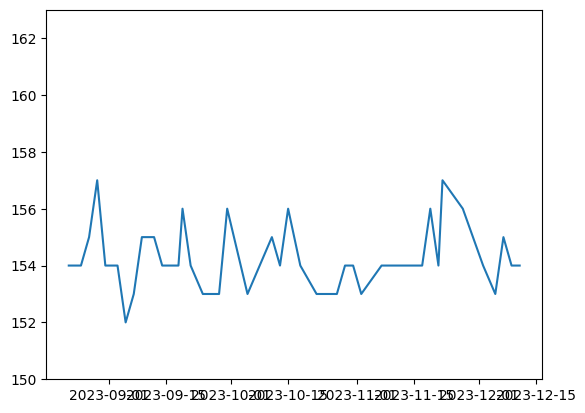

In [23]:
plt.plot(sem_1['Date'], sem_1['Weight'])
plt.ylim(150, 163)